# OSM Land Use Features - Viladecans

Downloads OSM land use polygons for Viladecans (landuse + leisure parks), computes the percentage
of green, commercial, and industrial area within a 50 m buffer of each street segment,
and exports `data/osm_landuse_features.csv`.
Roads loaded from `../layers/VIL_noise_streets.gpkg`.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import osmnx as ox
import os

## Load roads

In [2]:
osm_roads = gpd.read_file("../layers/VIL_noise_streets.gpkg")
print(osm_roads.crs)
print(osm_roads.shape)
print(osm_roads.columns.tolist())
print("Number of street segments:", len(osm_roads))

EPSG:25831
(1613, 12)
['segment_id', 'highway', 'name', 'length', 'db_day', 'db_evening', 'db_night', 'noise_day', 'noise_evening', 'noise_night', 'distance', 'geometry']
Number of street segments: 1613


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


## Load / Download OSM Land Use

In [3]:
landuse_cache = 'data/vil_osm_landuse.gpkg'
os.makedirs('data', exist_ok=True)

if os.path.exists(landuse_cache):
    osm_landuse = gpd.read_file(landuse_cache)
    print(f'Loaded from cache: {len(osm_landuse)} polygons')
else:
    print('Downloading landuse from OSM...')

    lu = ox.features_from_place('Viladecans, Spain', tags={'landuse': True})
    lu = lu[lu.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
    lu['fclass'] = lu['landuse'].apply(lambda x: x[0] if isinstance(x, list) else str(x))

    parks = ox.features_from_place('Viladecans, Spain',
                                    tags={'leisure': ['park', 'garden', 'nature_reserve', 'recreation_ground']})
    parks = parks[parks.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
    parks['fclass'] = parks['leisure'].apply(
        lambda x: 'recreation_ground' if str(x) == 'recreation_ground' else 'park')

    combined = gpd.GeoDataFrame(
        pd.concat([lu[['fclass', 'geometry']], parks[['fclass', 'geometry']]], ignore_index=True),
        crs='EPSG:4326'
    ).reset_index(drop=True)
    combined = combined[combined.geometry.notna()]
    combined.to_file(landuse_cache, driver='GPKG')
    osm_landuse = combined
    print(f'Downloaded and cached: {len(osm_landuse)} polygons')

if osm_landuse.crs != osm_roads.crs:
    osm_landuse = osm_landuse.to_crs(osm_roads.crs)

print('CRS:', osm_landuse.crs)
print('Shape:', osm_landuse.shape)
display(osm_landuse.head(2))

Loaded from cache: 854 polygons
CRS: EPSG:25831
Shape: (854, 2)


,fclass,geometry
0,residential,"MULTIPOLYGON (((418340.29 4568845.316, 418345...."
1,forest,"MULTIPOLYGON (((420122.615 4569561.771, 420125..."


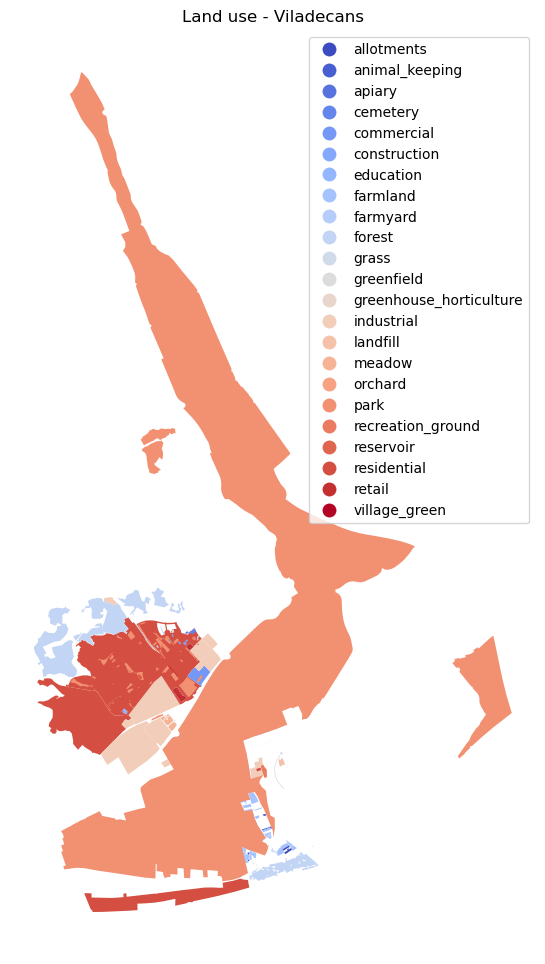

In [4]:
ax = osm_landuse.plot(cmap='coolwarm', column='fclass', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Land use - Viladecans')
ax.set_axis_off()

## Get the green areas

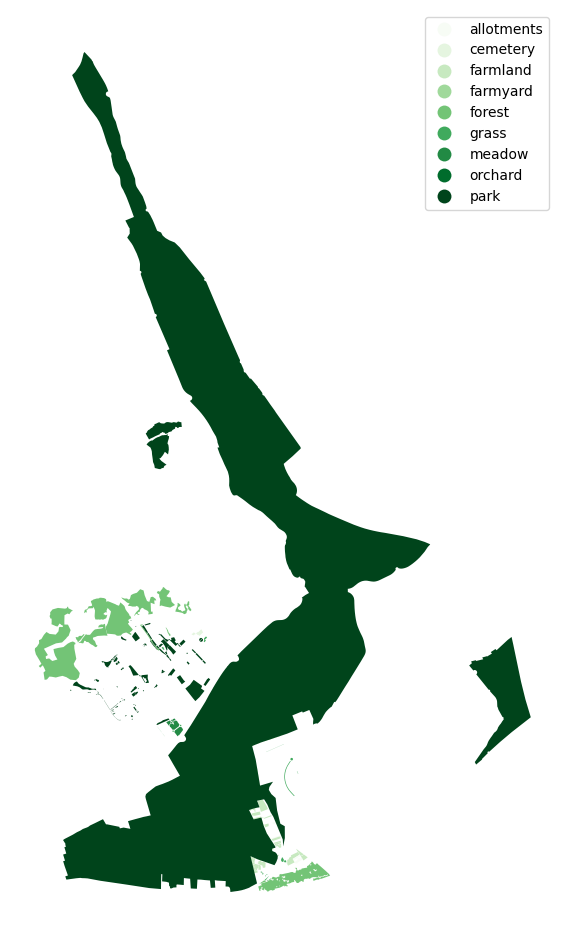

In [5]:
green_categories = ['forest', 'grass', 'meadow', 'orchard', 'vineyard', 'farmland', 'farmyard', 'park','heath', 'scrub', 'meadow', 'orchard', 'allotments', 'cemetery']  
green_land = osm_landuse[osm_landuse['fclass'].isin(green_categories)]

ax = green_land.plot(cmap="Greens", column='fclass', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_axis_off()

## Calculate green percentage in 50 m buffer

In [6]:
# 1. Buffer the streets
osm_roads['buffer'] = osm_roads.geometry.buffer(50)  # adjust buffer size as needed

# 2. Calculate percentage of buffer covered by green
def calc_green_coverage(buffer_geom, green_gdf):
    # Get all green polygons that intersect the buffer
    intersecting = green_gdf[green_gdf.intersects(buffer_geom)]
    if intersecting.empty:
        return 0
    # Union all green polygons first to avoid double-counting overlapping areas
    green_union = intersecting.union_all()
    intersection_area = green_union.intersection(buffer_geom).area
    # Calculate percentage
    return (intersection_area / buffer_geom.area) * 100 if buffer_geom.area > 0 else 0

osm_roads['green_pct'] = osm_roads['buffer'].apply(lambda buf: calc_green_coverage(buf, green_land))

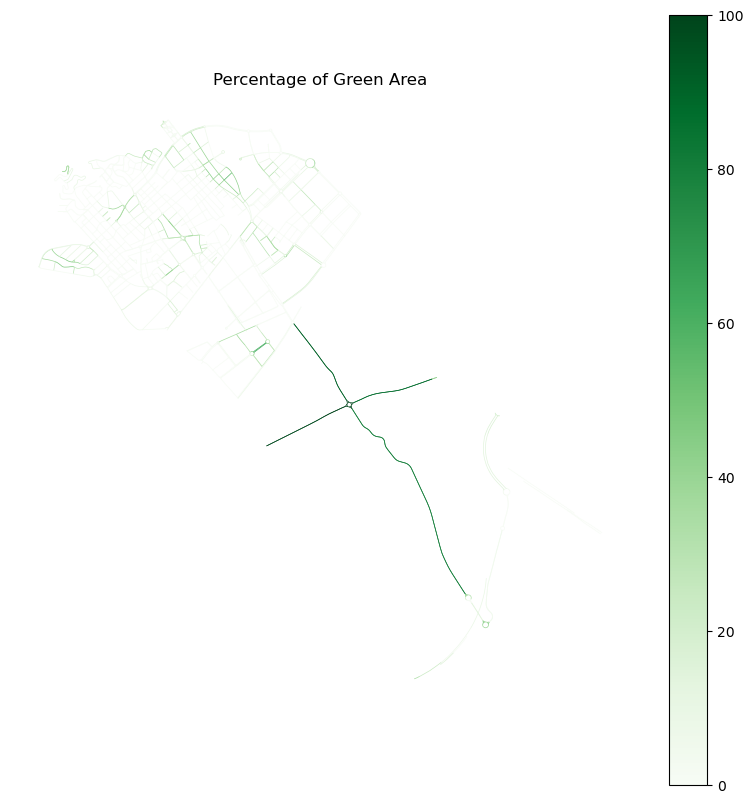

In [7]:
ax = osm_roads.plot(column='green_pct', cmap='Greens', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Percentage of Green Area')
ax.set_axis_off()

In [8]:
commercial_land = osm_landuse[osm_landuse['fclass'] == 'commercial']

def calc_commercial_coverage(buffer_geom, commercial_gdf):
    intersecting = commercial_gdf[commercial_gdf.intersects(buffer_geom)]
    if intersecting.empty:
        return 0
    # Union all polygons first to avoid double-counting overlapping areas
    commercial_union = intersecting.union_all()
    intersection_area = commercial_union.intersection(buffer_geom).area
    return (intersection_area / buffer_geom.area) * 100 if buffer_geom.area > 0 else 0

osm_roads['commercial_pct'] = osm_roads['buffer'].apply(lambda buf: calc_commercial_coverage(buf, commercial_land))

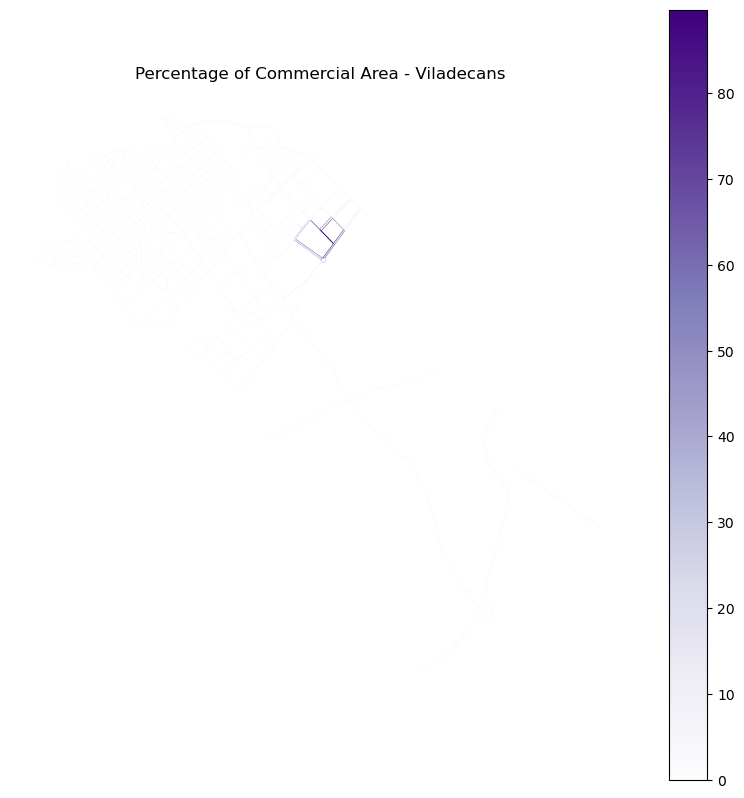

In [9]:
ax = osm_roads.plot(column='commercial_pct', cmap='Purples', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Percentage of Commercial Area - Viladecans')
ax.set_axis_off()

In [10]:
industrial_land = osm_landuse[osm_landuse['fclass'] == 'industrial']

def calc_industrial_coverage(buffer_geom, industrial_gdf):
    intersecting = industrial_gdf[industrial_gdf.intersects(buffer_geom)]
    if intersecting.empty:
        return 0
    # Union all polygons first to avoid double-counting overlapping areas
    industrial_union = intersecting.union_all()
    intersection_area = industrial_union.intersection(buffer_geom).area
    return (intersection_area / buffer_geom.area) * 100 if buffer_geom.area > 0 else 0

osm_roads['industrial_pct'] = osm_roads['buffer'].apply(lambda buf: calc_industrial_coverage(buf, industrial_land))

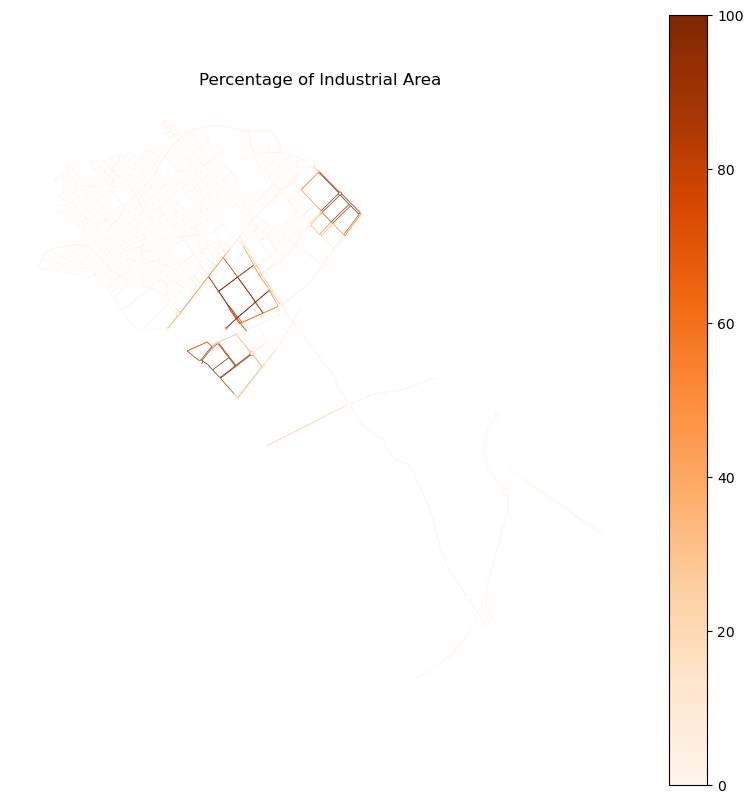

In [11]:
ax = osm_roads.plot(column='industrial_pct', cmap='Oranges', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Percentage of Industrial Area')
ax.set_axis_off()

## Merge and Export

In [12]:
dataset = pd.DataFrame({
    "road_id": osm_roads["segment_id"],
    "green": osm_roads["green_pct"],
    "industrial": osm_roads["industrial_pct"],
    "commercial": osm_roads["commercial_pct"]
})

dataset = dataset.fillna(0)
display(dataset.head(5))

output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_landuse_features.csv"), index=False)
print("Exported osm_landuse_features.csv")

,road_id,green,industrial,commercial
0,206378333_6315715548_0,0.000000,64.460544,0.0
1,208568922_208568921_0,0.147571,0.000000,0.0
2,208568926_208568922_1,15.415345,0.000000,0.0
3,208595138_208595144_0,9.872402,0.000000,0.0
4,208595144_2332249073_0,6.551946,0.000000,0.0


Exported osm_landuse_features.csv
